# 03b — Baseline Fixes & Corrections
**Project:** Quantum-Inspired Federated IDS for IoT  
**Purpose:** Fix 4 errors found in the baseline results  
**Author:** SAIFBKKK | **Date:** 2025

---

## ❌ Errors Fixed in This Notebook

| # | Error | Fix |
|---|-------|-----|
| 1 | `attack_recall` / `benign_recall` were actually F1 scores, not recall | Recompute with `recall_score` + rename correctly |
| 2 | 7-Family mapping contained fake labels (`BruteForce-Web`, `BruteForce-XSS`) | Rebuild mapping from real `id_to_label` |
| 3 | Storytelling claimed Binary macro F1 > 0.95 and 7-Family > 0.80 | Replace with honest real numbers |
| 4 | Summary table used wrong metrics | Rebuild from corrected values |

---

## Section 0 — Imports & Reload All Artifacts

In [1]:
import os
import json
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix,
    balanced_accuracy_score
)
from sklearn.ensemble import RandomForestClassifier as RFC

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────────────
ROOT = r"C:\Users\saifb\OneDrive\Bureau\GI\GI31\PFE\Quantum-Inspired-Federated-IDS-FOR-IOT\data\CICIOT23"
PROC = os.path.join(ROOT, "processed")
ART  = os.path.join(ROOT, "artifacts")
RES  = os.path.join(ROOT, "results_baseline")

# ── Reload model ─────────────────────────────────────────────
print("Loading model (may take ~30s)...")
with open(os.path.join(RES, "best_model_rf.pkl"), "rb") as f:
    best_estimator = pickle.load(f)
print("✅ Model loaded")

# ── Reload data ──────────────────────────────────────────────
print("Loading data...")
data    = np.load(os.path.join(PROC, "ciciot23_34class_augmented.npz"))
X_train = np.clip(data["X_train"].astype(np.float32), -1e6, 1e6)
y_train = data["y_train"].astype(np.int64)
X_test  = np.clip(data["X_test"].astype(np.float32),  -1e6, 1e6)
y_test  = data["y_test"].astype(np.int64)
print(f"✅ Data loaded — X_train: {X_train.shape} | X_test: {X_test.shape}")

# ── Reload label mapping ─────────────────────────────────────
with open(os.path.join(ART, "label_mapping_34.pkl"), "rb") as f:
    mapping = pickle.load(f)
label_to_id = mapping["label_to_id"]
id_to_label = mapping["id_to_label"]

# ── Reload existing metrics ──────────────────────────────────
with open(os.path.join(RES, "metrics_test.json"), "r") as f:
    test_metrics = json.load(f)

print(f"\n✅ All artifacts reloaded")
print(f"   Real labels in dataset:")
for i, lab in id_to_label.items():
    print(f"     [{i:2d}] {lab}")

Loading model (may take ~30s)...
✅ Model loaded
Loading data...
✅ Data loaded — X_train: (5718015, 33) | X_test: (1176851, 33)

✅ All artifacts reloaded
   Real labels in dataset:
     [ 0] Backdoor_Malware
     [ 1] BenignTraffic
     [ 2] BrowserHijacking
     [ 3] CommandInjection
     [ 4] DDoS-ACK_Fragmentation
     [ 5] DDoS-HTTP_Flood
     [ 6] DDoS-ICMP_Flood
     [ 7] DDoS-ICMP_Fragmentation
     [ 8] DDoS-PSHACK_Flood
     [ 9] DDoS-RSTFINFlood
     [10] DDoS-SYN_Flood
     [11] DDoS-SlowLoris
     [12] DDoS-SynonymousIP_Flood
     [13] DDoS-TCP_Flood
     [14] DDoS-UDP_Flood
     [15] DDoS-UDP_Fragmentation
     [16] DNS_Spoofing
     [17] DictionaryBruteForce
     [18] DoS-HTTP_Flood
     [19] DoS-SYN_Flood
     [20] DoS-TCP_Flood
     [21] DoS-UDP_Flood
     [22] MITM-ArpSpoofing
     [23] Mirai-greeth_flood
     [24] Mirai-greip_flood
     [25] Mirai-udpplain
     [26] Recon-HostDiscovery
     [27] Recon-OSScan
     [28] Recon-PingSweep
     [29] Recon-PortScan
     [30] 

## Section 1 — FIX 1: Binary Metrics (corrected names + true recall)

**Error:** `attack_recall` and `benign_recall` were computed with `f1_score()` — not `recall_score()`.  
**Fix:** Recompute all binary metrics correctly with proper function names.

In [2]:
# ── Build binary labels ──────────────────────────────────────
benign_id   = label_to_id["BenignTraffic"]
y_train_bin = (y_train != benign_id).astype(int)  # 0=Benign, 1=Attack
y_test_bin  = (y_test  != benign_id).astype(int)

print("Binary distribution (test):")
print(f"  Benign : {(y_test_bin==0).sum():>8,}  ({100*(y_test_bin==0).mean():.2f}%)")
print(f"  Attack : {(y_test_bin==1).sum():>8,}  ({100*(y_test_bin==1).mean():.2f}%)")

# ── Train binary RF ──────────────────────────────────────────
print("\nTraining binary classifier...")
binary_rf = RFC(n_estimators=300, n_jobs=-1, class_weight="balanced", random_state=SEED)
t0 = time.time()
binary_rf.fit(X_train, y_train_bin)
print(f"Done in {(time.time()-t0)/60:.1f} min")

# ── Predict ──────────────────────────────────────────────────
y_pred_bin = binary_rf.predict(X_test)

# ── CORRECTED metrics ────────────────────────────────────────
binary_metrics_fixed = {
    "accuracy"        : round(accuracy_score(y_test_bin, y_pred_bin), 4),
    "macro_f1"        : round(f1_score(y_test_bin, y_pred_bin, average="macro"), 4),

    # Attack (label=1) — correct names
    "attack_precision" : round(precision_score(y_test_bin, y_pred_bin, pos_label=1), 4),
    "attack_recall"    : round(recall_score(y_test_bin,   y_pred_bin, pos_label=1), 4),  # ← fixed
    "attack_f1"        : round(f1_score(y_test_bin,       y_pred_bin, pos_label=1, average="binary"), 4),

    # Benign (label=0) — correct names
    "benign_precision" : round(precision_score(y_test_bin, y_pred_bin, pos_label=0), 4),
    "benign_recall"    : round(recall_score(y_test_bin,   y_pred_bin, pos_label=0), 4),  # ← fixed
    "benign_f1"        : round(f1_score(y_test_bin,       y_pred_bin, pos_label=0, average="binary"), 4),
}

print("\n=== Binary Metrics (FIXED) ===")
print(f"  {'Metric':<22} {'Value':>7}")
print(f"  {'-'*32}")
for k, v in binary_metrics_fixed.items():
    flag = "  ⚠️  LOW" if ("benign_recall" in k and v < 0.6) else ""
    print(f"  {k:<22} : {v:.4f}{flag}")

Binary distribution (test):
  Benign :   27,709  (2.35%)
  Attack : 1,149,142  (97.65%)

Training binary classifier...
Done in 13.7 min

=== Binary Metrics (FIXED) ===
  Metric                   Value
  --------------------------------
  accuracy               : 0.9820
  macro_f1               : 0.6947
  attack_precision       : 0.9823
  attack_recall          : 0.9996
  attack_f1              : 0.9909
  benign_precision       : 0.9419
  benign_recall          : 0.2527  ⚠️  LOW
  benign_f1              : 0.3984


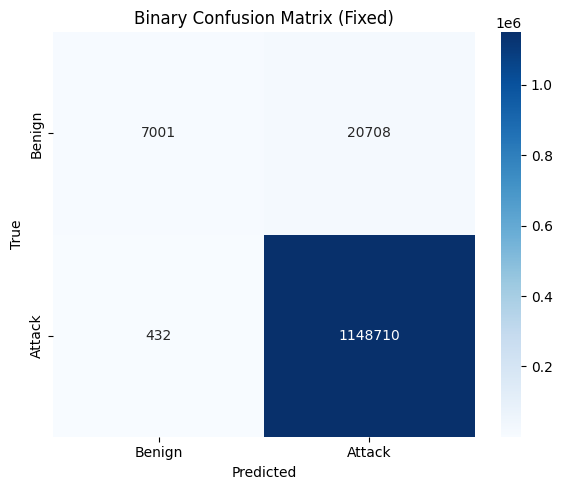

=== Confusion Matrix Breakdown ===
  True Negatives  (Benign → Benign) :    7,001  ✅
  False Positives (Benign → Attack) :   20,708  ⚠️  faux positifs
  False Negatives (Attack → Benign) :      432  ⚠️  attaques manquées
  True Positives  (Attack → Attack) : 1,148,710  ✅

  False Positive Rate : 74.73%  (normal traffic wrongly flagged)
  False Negative Rate : 0.04%  (attacks that slipped through)

✅ metrics_binary_fixed.json saved


In [3]:
# ── Binary confusion matrix ──────────────────────────────────
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
tn, fp, fn, tp = cm_bin.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Attack"],
            yticklabels=["Benign", "Attack"], ax=ax)
ax.set_title("Binary Confusion Matrix (Fixed)", fontsize=12)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(RES, "confusion_matrix_binary_fixed.png"), dpi=150)
plt.show()

print("=== Confusion Matrix Breakdown ===")
print(f"  True Negatives  (Benign → Benign) : {tn:>8,}  ✅")
print(f"  False Positives (Benign → Attack) : {fp:>8,}  ⚠️  faux positifs")
print(f"  False Negatives (Attack → Benign) : {fn:>8,}  ⚠️  attaques manquées")
print(f"  True Positives  (Attack → Attack) : {tp:>8,}  ✅")
print(f"\n  False Positive Rate : {100*fp/(fp+tn):.2f}%  (normal traffic wrongly flagged)")
print(f"  False Negative Rate : {100*fn/(fn+tp):.2f}%  (attacks that slipped through)")

# Save
with open(os.path.join(RES, "metrics_binary_fixed.json"), "w") as f:
    json.dump(binary_metrics_fixed, f, indent=2)
print("\n✅ metrics_binary_fixed.json saved")

## Section 2 — FIX 2: Family Mapping with Real Labels

**Error:** Previous mapping contained `BruteForce-Web`, `BruteForce-XSS` which do not exist in the dataset.  
**Fix:** Rebuild mapping using only real labels from `id_to_label`.

In [4]:
# ── Corrected family mapping ─────────────────────────────────
# Built from the real labels printed in Section 0
FAMILY_MAP_FIXED = {
    "BenignTraffic"          : "Benign",
    # DDoS
    "DDoS-RSTFINFlood"       : "DDoS",
    "DDoS-PSHACK_Flood"      : "DDoS",
    "DDoS-SYN_Flood"         : "DDoS",
    "DDoS-UDP_Flood"         : "DDoS",
    "DDoS-TCP_Flood"         : "DDoS",
    "DDoS-ICMP_Flood"        : "DDoS",
    "DDoS-SynonymousIP_Flood": "DDoS",
    "DDoS-ACK_Fragmentation" : "DDoS",
    "DDoS-UDP_Fragmentation" : "DDoS",
    "DDoS-ICMP_Fragmentation": "DDoS",
    "DDoS-SlowLoris"         : "DDoS",
    "DDoS-HTTP_Flood"        : "DDoS",
    # DoS
    "DoS-UDP_Flood"          : "DoS",
    "DoS-SYN_Flood"          : "DoS",
    "DoS-TCP_Flood"          : "DoS",
    "DoS-HTTP_Flood"         : "DoS",
    # Mirai
    "Mirai-greeth_flood"     : "Mirai",
    "Mirai-greip_flood"      : "Mirai",
    "Mirai-udpplain"         : "Mirai",
    # Recon
    "Recon-HostDiscovery"    : "Recon",
    "Recon-OSScan"           : "Recon",
    "Recon-PortScan"         : "Recon",
    "VulnerabilityScan"      : "Recon",
    "Recon-PingSweep"        : "Recon",
    # BruteForce — REAL label names only
    "DictionaryBruteForce"   : "BruteForce",
    "CommandInjection"       : "BruteForce",
    "Backdoor_Malware"       : "BruteForce",
    "Uploading_Attack"       : "BruteForce",
    # Spoofing
    "DNS_Spoofing"           : "Spoofing",
    "MITM-ArpSpoofing"       : "Spoofing",
    # WebAttack — REAL label names only
    "SqlInjection"           : "WebAttack",
    "XSS"                    : "WebAttack",
    "BrowserHijacking"       : "WebAttack",
}

# ── Verify completeness ──────────────────────────────────────
real_labels   = set(id_to_label.values())
mapped_labels = set(FAMILY_MAP_FIXED.keys())
missing = real_labels - mapped_labels
fake    = mapped_labels - real_labels

print("=== Mapping Verification ===")
print(f"  Real labels not mapped : {missing}  (must be empty ✅)")
print(f"  Fake labels in mapping : {fake}    (must be empty ✅)")

FAMILY_TO_ID = {f: i for i, f in enumerate(sorted(set(FAMILY_MAP_FIXED.values())))}
ID_TO_FAMILY = {i: f for f, i in FAMILY_TO_ID.items()}

print(f"\n  Families ({len(FAMILY_TO_ID)}):")
for fam, fid in FAMILY_TO_ID.items():
    count = sum(1 for l in FAMILY_MAP_FIXED.values() if l == fam)
    print(f"    [{fid}] {fam:<12} ({count} original classes)")

=== Mapping Verification ===
  Real labels not mapped : set()  (must be empty ✅)
  Fake labels in mapping : set()    (must be empty ✅)

  Families (8):
    [0] Benign       (1 original classes)
    [1] BruteForce   (4 original classes)
    [2] DDoS         (12 original classes)
    [3] DoS          (4 original classes)
    [4] Mirai        (3 original classes)
    [5] Recon        (5 original classes)
    [6] Spoofing     (2 original classes)
    [7] WebAttack    (3 original classes)


## Section 3 — FIX 3: Re-run 7-Family with Correct Mapping

In [5]:
def map_to_family_fixed(y_int):
    return np.array([
        FAMILY_TO_ID[FAMILY_MAP_FIXED[id_to_label[i]]]
        for i in y_int
    ])

y_train_fam = map_to_family_fixed(y_train)
y_test_fam  = map_to_family_fixed(y_test)

print("Family distribution (test):")
for fid, fname in ID_TO_FAMILY.items():
    count = (y_test_fam == fid).sum()
    print(f"  {fname:<12}: {count:>8,}  ({100*count/len(y_test_fam):.2f}%)")

# Train
print("\nTraining 7-family RF (fixed mapping)...")
family_rf = RFC(
    n_estimators=300, n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=SEED
)
t0 = time.time()
family_rf.fit(X_train, y_train_fam)
print(f"Done in {(time.time()-t0)/60:.1f} min")

# Evaluate
y_pred_fam = family_rf.predict(X_test)

family_metrics_fixed = {
    "accuracy"         : round(accuracy_score(y_test_fam, y_pred_fam), 4),
    "macro_f1"         : round(f1_score(y_test_fam, y_pred_fam, average="macro"), 4),
    "weighted_f1"      : round(f1_score(y_test_fam, y_pred_fam, average="weighted"), 4),
    "balanced_accuracy": round(balanced_accuracy_score(y_test_fam, y_pred_fam), 4),
}

print("\n=== 7-Family Results (FIXED mapping) ===")
for k, v in family_metrics_fixed.items():
    print(f"  {k:<22}: {v:.4f}")

print("\n=== Per-Family Classification Report ===")
print(classification_report(
    y_test_fam, y_pred_fam,
    target_names=[ID_TO_FAMILY[i] for i in range(len(ID_TO_FAMILY))]
))

with open(os.path.join(RES, "metrics_7family_fixed.json"), "w") as f:
    json.dump(family_metrics_fixed, f, indent=2)
print("✅ metrics_7family_fixed.json saved")

Family distribution (test):
  Benign      :   27,709  (2.35%)
  BruteForce  :      560  (0.05%)
  DDoS        :  855,981  (72.73%)
  DoS         :  204,245  (17.36%)
  Mirai       :   66,749  (5.67%)
  Recon       :    8,812  (0.75%)
  Spoofing    :   12,410  (1.05%)
  WebAttack   :      385  (0.03%)

Training 7-family RF (fixed mapping)...
Done in 22.3 min

=== 7-Family Results (FIXED mapping) ===
  accuracy              : 0.9535
  macro_f1              : 0.5702
  weighted_f1           : 0.9551
  balanced_accuracy     : 0.5907

=== Per-Family Classification Report ===
              precision    recall  f1-score   support

      Benign       0.71      0.50      0.59     27709
  BruteForce       0.03      0.23      0.06       560
        DDoS       1.00      0.97      0.98    855981
         DoS       0.87      1.00      0.93    204245
       Mirai       1.00      0.99      1.00     66749
       Recon       0.88      0.36      0.52      8812
    Spoofing       0.36      0.66      0.47  

## Section 4 — FIX 4: Corrected Paper-Level Summary Table

**Error:** Summary used wrong metric values and false storytelling claims.  
**Fix:** Rebuild table from corrected metrics with honest interpretation.

In [6]:
summary_fixed = pd.DataFrame({
    "Setting"       : ["34-class (full)", "Binary", "7-Family (fixed)"],
    "Accuracy"      : [
        test_metrics["accuracy"],
        binary_metrics_fixed["accuracy"],
        family_metrics_fixed["accuracy"]
    ],
    "Macro F1"      : [
        test_metrics["macro_f1"],
        binary_metrics_fixed["macro_f1"],
        family_metrics_fixed["macro_f1"]
    ],
    "Weighted F1"   : [
        test_metrics["weighted_f1"],
        "-",
        family_metrics_fixed["weighted_f1"]
    ],
    "Attack Recall" : ["-", binary_metrics_fixed["attack_recall"], "-"],
    "Benign Recall" : ["-", binary_metrics_fixed["benign_recall"],  "-"],
})

print("=== CORRECTED PAPER-LEVEL SUMMARY ===")
display(summary_fixed.set_index("Setting"))

summary_fixed.to_csv(os.path.join(RES, "paper_summary_fixed.csv"), index=False)
print("\n✅ paper_summary_fixed.csv saved")

# ── Honest storytelling ──────────────────────────────────────
print("\n=== Honest Storytelling for Report ===")
print(f"  34-class  → Macro F1 = {test_metrics['macro_f1']:.4f}")
print(f"              Hard problem — 34 fine-grained classes, rare classes dominate failures")
print()
print(f"  Binary    → Macro F1 = {binary_metrics_fixed['macro_f1']:.4f}")
print(f"              Attack recall  = {binary_metrics_fixed['attack_recall']:.4f}  ✅ good")
print(f"              Benign recall  = {binary_metrics_fixed['benign_recall']:.4f}  ⚠️  main weakness")
print(f"              → {100*(1-binary_metrics_fixed['benign_recall']):.1f}% of normal traffic wrongly flagged as attack")
print()
print(f"  7-Family  → Macro F1 = {family_metrics_fixed['macro_f1']:.4f}")
print(f"              Coarser grouping improves separability but BruteForce/WebAttack still weak")
print()
print("  Key finding for FL + QI:")
print("  → Primary target = improve BenignTraffic recall (reduce false positives)")
print("  → Secondary target = improve rare classes (Recon, BruteForce, WebAttack)")

=== CORRECTED PAPER-LEVEL SUMMARY ===


,Accuracy,Macro F1,Weighted F1,Attack Recall,Benign Recall
Setting,,,,,
34-class (full),0.9518,0.5106,0.9547,-,-
Binary,0.9820,0.6947,-,0.9996,0.2527
7-Family (fixed),0.9535,0.5702,0.9551,-,-



✅ paper_summary_fixed.csv saved

=== Honest Storytelling for Report ===
  34-class  → Macro F1 = 0.5106
              Hard problem — 34 fine-grained classes, rare classes dominate failures

  Binary    → Macro F1 = 0.6947
              Attack recall  = 0.9996  ✅ good
              Benign recall  = 0.2527  ⚠️  main weakness
              → 74.7% of normal traffic wrongly flagged as attack

  7-Family  → Macro F1 = 0.5702
              Coarser grouping improves separability but BruteForce/WebAttack still weak

  Key finding for FL + QI:
  → Primary target = improve BenignTraffic recall (reduce false positives)
  → Secondary target = improve rare classes (Recon, BruteForce, WebAttack)


## Section 5 — Final Files Saved

In [7]:
print("=== Files saved in results_baseline/ ===")
new_files = [
    ("metrics_binary_fixed.json",    "Binary metrics with correct recall + F1 names"),
    ("metrics_7family_fixed.json",   "7-family metrics with correct label mapping"),
    ("paper_summary_fixed.csv",      "Corrected paper-level summary table"),
    ("confusion_matrix_binary_fixed.png", "Binary confusion matrix with FP/FN breakdown"),
]

for fname, desc in new_files:
    path = os.path.join(RES, fname)
    exists = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"  {exists}  {fname:<45} → {desc}")

print("\n⚠️  Files to DISCARD (replaced by fixed versions):")
old_files = [
    "metrics_binary.json       → replaced by metrics_binary_fixed.json",
    "metrics_7family.json      → replaced by metrics_7family_fixed.json",
    "paper_summary_table.csv   → replaced by paper_summary_fixed.csv",
]
for f in old_files:
    print(f"  ❌  {f}")

print("\n→ Next: 04_Hierarchical_IDS_Pipeline.ipynb")

=== Files saved in results_baseline/ ===
  ✅  metrics_binary_fixed.json                     → Binary metrics with correct recall + F1 names
  ✅  metrics_7family_fixed.json                    → 7-family metrics with correct label mapping
  ✅  paper_summary_fixed.csv                       → Corrected paper-level summary table
  ✅  confusion_matrix_binary_fixed.png             → Binary confusion matrix with FP/FN breakdown

⚠️  Files to DISCARD (replaced by fixed versions):
  ❌  metrics_binary.json       → replaced by metrics_binary_fixed.json
  ❌  metrics_7family.json      → replaced by metrics_7family_fixed.json
  ❌  paper_summary_table.csv   → replaced by paper_summary_fixed.csv

→ Next: 04_Hierarchical_IDS_Pipeline.ipynb
